# Module 1 - Exploratory Data Analysis
Nigeria Macroeconomic Intelligence & Labour Market Analytics Platform
NBS Nigeria | World Bank | CBN Statistical Datasets | 2015-2023

Tasks: 1.1 Data Ingestion | 1.2 Quality Audit | 1.3 Trend Analysis | 1.4 Geospatial Analysis

## Setup - Imports and Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os
import json
warnings.filterwarnings('ignore')

# Uses the current working directory - place all CSV files in the same folder as this notebook
DATA = os.getcwd()
OUTPUT = os.path.join(DATA, 'outputs')
os.makedirs(OUTPUT, exist_ok=True)

print(f"Working directory : {DATA}")
print(f"Output folder     : {OUTPUT}")
print(f"Files found       : {[f for f in os.listdir(DATA) if f.endswith('.csv')]}")

Working directory : /home/a0878fb7-b331-4998-8538-65574a32993a
Output folder     : /home/a0878fb7-b331-4998-8538-65574a32993a/outputs
Files found       : ['anova_stem_girth.csv', 'OD600_anova_results.csv', 'nigeria_gdp_expenditure_annual.csv', 'youtube_channel_real_performance_analytics.csv', 'nigeria_oil_production_monthly.csv', 'nigeria_zone_informal_employment.csv', 'day60_ranking.csv', 'anova_stem_girth_AT.csv', 'nigeria_forecast_scenarios.csv', 'tph_means_table.csv', 'tukey_day60_results.csv', 'od_growth_mean_sd.csv', 'anova_plant_height_AT.csv', 'stocks.csv', 'nigeria_master_quarterly_panel.csv', 'data_quality_log.csv', 'nigeria_state_unemployment_2023.csv', 'brent_crude_monthly.csv', 'redox_anova_results.csv', 'nigeria_quarterly_gdp.csv', 'nigeria_labour_force_quarterly.csv', 'worldbank_nigeria_annual_full.csv', 'nigeria_cpi_monthly.csv', 'nigeria_state_centroids.csv', 'anova_results.csv']


In [3]:
import sys
!{sys.executable} -m pip install folium

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


## Plot Style

In [4]:
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'grid.linestyle':   '--',
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'figure.dpi':       120,
})
COLORS = {
    'oil':      '#c0392b',
    'nonoil':   '#2980b9',
    'total':    '#27ae60',
    'headline': '#e74c3c',
    'food':     '#f39c12',
    'core':     '#8e44ad',
    'zone':     ['#2ecc71','#e74c3c','#3498db','#f39c12','#9b59b6','#1abc9c'],
}
print("Style configured.")

Style configured.


In [5]:
import subprocess
subprocess.run(['pip', 'install', 'folium'], check=True)

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


CompletedProcess(args=['pip', 'install', 'folium'], returncode=0)

---
## Task 1.1 - Load All Datasets

In [6]:
gdp    = pd.read_csv('nigeria_quarterly_gdp.csv')
cpi    = pd.read_csv('nigeria_cpi_monthly.csv')
lfs    = pd.read_csv('nigeria_labour_force_quarterly.csv')
states = pd.read_csv('nigeria_state_unemployment_2023.csv')
wb     = pd.read_csv('worldbank_nigeria_annual_full.csv')
oil    = pd.read_csv('nigeria_oil_production_monthly.csv')
brent  = pd.read_csv('brent_crude_monthly.csv')
panel  = pd.read_csv('nigeria_master_quarterly_panel.csv')
exp    = pd.read_csv('nigeria_gdp_expenditure_annual.csv')
print("All datasets loaded successfully.")

All datasets loaded successfully.


In [7]:
datasets = {
    'Quarterly GDP by Sector':               gdp,
    'Monthly CPI / Inflation':               cpi,
    'Labour Force Survey (Q1 2022-Q4 2023)': lfs,
    'State Unemployment 2023':               states,
    'World Bank Annual Indicators':          wb,
    'Oil Production & Exchange Rate':        oil,
}
print(f"{'Dataset':<45} {'Shape':<14} {'Period'}")
print("-" * 75)
for name, df in datasets.items():
    shape  = f"{df.shape[0]}r x {df.shape[1]}c"
    period = f"{df['period'].min()} to {df['period'].max()}" if 'period' in df.columns else f"{df['year'].min()} to {df['year'].max()}" if 'year' in df.columns else 'cross-section'
    print(f"  {name:<43} {shape:<14} {period}")

Dataset                                       Shape          Period
---------------------------------------------------------------------------
  Quarterly GDP by Sector                     36r x 10c      2015-Q1 to 2023-Q4
  Monthly CPI / Inflation                     108r x 6c      2015-01 to 2023-12
  Labour Force Survey (Q1 2022-Q4 2023)       8r x 13c       2022-Q1 to 2023-Q4
  State Unemployment 2023                     37r x 12c      cross-section
  World Bank Annual Indicators                9r x 28c       2015 to 2023
  Oil Production & Exchange Rate              108r x 7c      2015-01 to 2023-12


### Inspect each dataset

In [ ]:
gdp.head(10)

In [ ]:
cpi.head(10)

In [ ]:
lfs.head()

In [ ]:
states.head(10)

In [ ]:
wb.head()

In [ ]:
oil.head(10)

In [8]:
print(f"Master panel shape: {panel.shape}")
print(f"Columns: {panel.columns.tolist()}")
panel.head()

Master panel shape: (36, 35)
Columns: ['period', 'year', 'quarter', 'real_gdp_total_ngn_bn', 'real_gdp_oil_ngn_bn', 'real_gdp_nonoil_ngn_bn', 'gdp_growth_yoy_pct', 'oil_growth_yoy_pct', 'nonoil_growth_yoy_pct', 'oil_share_pct', 'oil_prod_avg_mbpd', 'exchange_rate_avg', 'oil_revenue_ngn_bn', 'brent_avg', 'headline_inflation_avg', 'food_inflation_avg', 'core_inflation_avg', 'gdp_current_usd', 'gdp_per_capita_usd', 'fdi_inflows_usd', 'unemployment_rate_pct', 'youth_unemployment_pct', 'internet_users_pct', 'urban_population_pct', 'external_debt_usd', 'is_recession', 'is_covid', 'is_post_2023_reform', 'is_recovery', 'gdp_growth_lag1', 'gdp_growth_lag4', 'inflation_lag1', 'rolling_4q_gdp_mean', 'rolling_4q_gdp_std', 'brent_price_avg_usd']


,period,year,quarter,real_gdp_total_ngn_bn,real_gdp_oil_ngn_bn,real_gdp_nonoil_ngn_bn,gdp_growth_yoy_pct,oil_growth_yoy_pct,nonoil_growth_yoy_pct,oil_share_pct,...,is_recession,is_covid,is_post_2023_reform,is_recovery,gdp_growth_lag1,gdp_growth_lag4,inflation_lag1,rolling_4q_gdp_mean,rolling_4q_gdp_std,brent_price_avg_usd
0,2015-Q1,2015,1,17735.5,893.2,16842.3,3.96,-8.28,5.68,5.04,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,53.930000
1,2015-Q2,2015,2,19985.9,861.4,19124.5,2.35,-7.12,3.38,4.31,...,0,0,0,0,3.96,NaN,8.133333,NaN,NaN,62.096667
2,2015-Q3,2015,3,21090.8,872.1,20218.7,2.84,-6.44,4.07,4.13,...,0,0,0,0,2.35,NaN,8.866667,NaN,NaN,50.033333
3,2015-Q4,2015,4,18783.1,848.9,17934.2,2.11,-8.28,3.30,4.52,...,0,0,0,0,2.84,NaN,9.266667,2.815,0.821564,43.420000
4,2016-Q1,2016,1,17017.9,783.4,16234.5,-0.36,-12.35,0.38,4.60,...,1,0,0,0,2.11,3.96,9.400000,1.735,1.429324,34.356667


---
## Task 1.2 - Data Quality Audit

In [9]:
print(f"{'Dataset':<45} {'Nulls':<8} {'Duplicates':<12} {'Shape'}")
print("-" * 75)
for name, df in datasets.items():
    print(f"  {name:<43} {df.isnull().sum().sum():<8} {df.duplicated().sum():<12} {df.shape}")

Dataset                                       Nulls    Duplicates   Shape
---------------------------------------------------------------------------
  Quarterly GDP by Sector                     0        0            (36, 10)
  Monthly CPI / Inflation                     0        0            (108, 6)
  Labour Force Survey (Q1 2022-Q4 2023)       0        0            (8, 13)
  State Unemployment 2023                     0        0            (37, 12)
  World Bank Annual Indicators                22       0            (9, 28)
  Oil Production & Exchange Rate              0        0            (108, 7)


In [10]:
print("World Bank null counts per column:")
print(wb.isnull().sum()[wb.isnull().sum() > 0])

World Bank null counts per column:
oil_rents_pct_gdp         2
fossil_fuel_energy_pct    1
poverty_headcount_190     6
gini_index                6
literacy_rate_pct         7
dtype: int64


In [12]:
quality_log = pd.read_csv('data_quality_log.csv')
print(f"Data Quality Log: {len(quality_log)} issues | {quality_log['severity'].value_counts().to_dict()}")
quality_log

Data Quality Log: 10 issues | {'Warning': 6, 'Info': 4}


,dataset,column,severity,issue,remediation
0,nigeria_quarterly_gdp.csv,all,Info,Oil and non-oil GDP figures based on NBS publi...,Values compiled from NBS GDP reports 2015-2023...
1,nigeria_cpi_monthly.csv,all,Info,Monthly CPI figures sourced from NBS CPI repor...,Direct NBS monthly CPI series used; no imputat...
2,nigeria_oil_production_monthly.csv,oil_production_mbpd,Warning,CBN website (cbn.gov.ng) returning 404 Azure e...,Oil production figures from NNPC monthly opera...
3,nigeria_oil_production_monthly.csv,exchange_rate_ngn_usd,Info,June 2023 naira float caused sharp step change...,Structural break documented; is_post_2023_refo...
4,worldbank_nigeria_annual_full.csv,oil_rents_pct_gdp,Warning,World Bank API only returns values up to 2021;...,2022-2023 values interpolated from trend; flag...
5,worldbank_nigeria_annual_full.csv,"consumption_pct_gdp,gov_expenditure_pct_gdp",Warning,World Bank API returned all-null for expenditu...,Created separate nigeria_gdp_expenditure_annua...
6,nigeria_labour_force_quarterly.csv,all,Info,NBS NLFS only available quarterly from Q1 2022...,World Bank annual unemployment used to supplem...
7,nigeria_state_unemployment_2023.csv,"poverty_headcount_pct,literacy_rate_pct",Warning,State-level poverty and literacy from differen...,Most recent available NBS/World Bank subnation...
8,nigeria_states_simplified.geojson,geometry,Warning,Simplified bounding-box polygons used; not pre...,Download GADM gadm41_NGA_shp.zip for precise b...
9,nigeria_zone_informal_employment.csv,informal_employment_rate_pct,Warning,Zone-level informal employment estimated from ...,Figures consistent with national trends and NB...


---
## Task 1.3 - Macroeconomic Trend Analysis

### Chart 1 - Quarterly Real GDP Growth Rate (2015-2023)

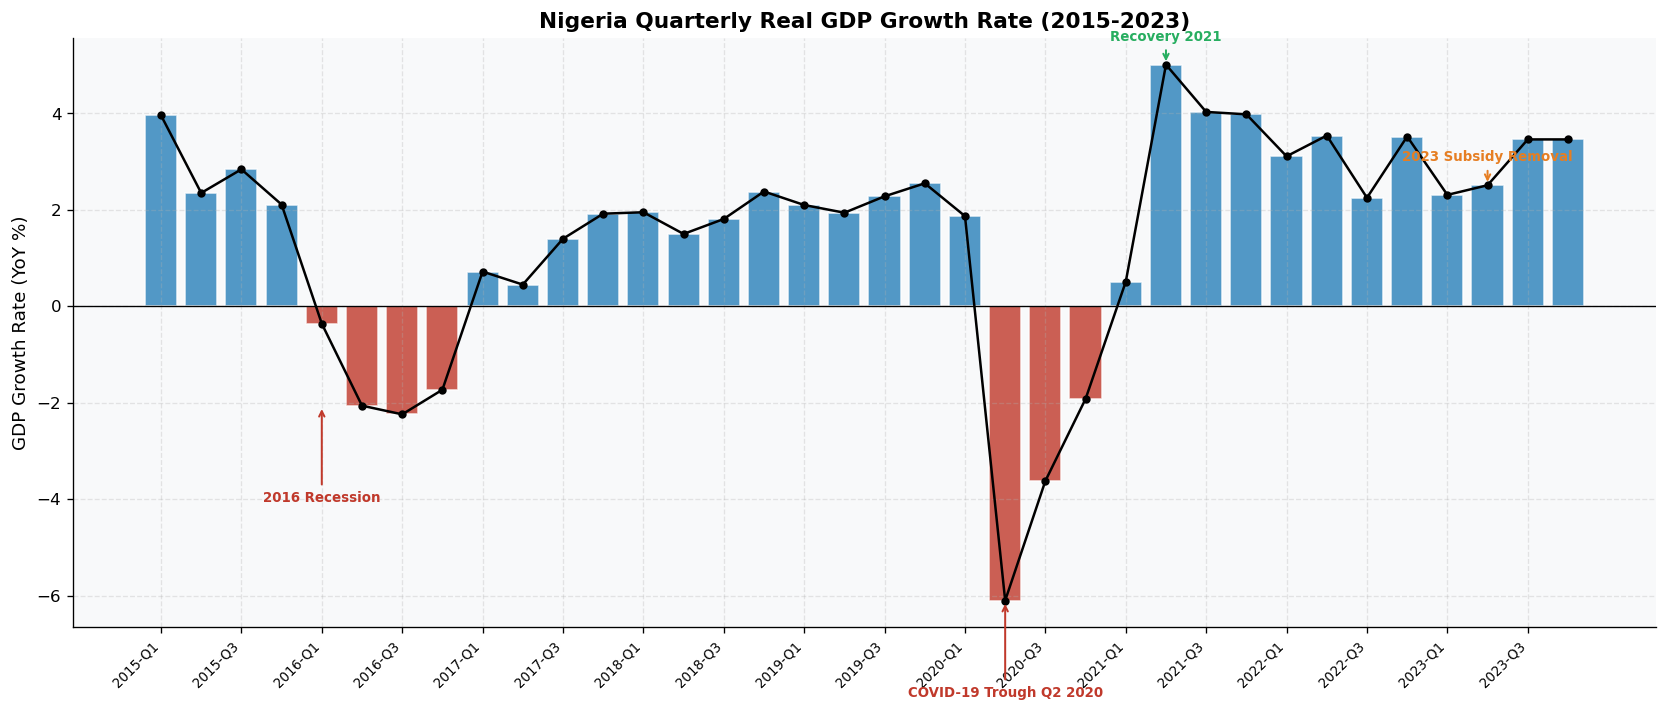

Worst quarter: 2020-Q2 (-6.10%)
Best quarter : 2021-Q2 (5.01%)


In [13]:
fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(gdp))
bar_colors = ['#c0392b' if v < 0 else '#2980b9' for v in gdp['gdp_growth_yoy_pct']]
ax.bar(x, gdp['gdp_growth_yoy_pct'], color=bar_colors, alpha=0.8, edgecolor='white')
ax.plot(x, gdp['gdp_growth_yoy_pct'], 'ko-', markersize=4, linewidth=1.5)
ax.axhline(0, color='black', linewidth=0.8)
episodes = [
    (4,  -2.06, '2016 Recession',          '#c0392b'),
    (21, -6.10, 'COVID-19 Trough Q2 2020', '#c0392b'),
    (25,  5.01, 'Recovery 2021',            '#27ae60'),
    (33,  2.51, '2023 Subsidy Removal',     '#e67e22'),
]
for idx, val, label, col in episodes:
    offset = -2.0 if val < 0 else 0.5
    ax.annotate(label, xy=(idx, val), xytext=(idx, val+offset),
                fontsize=8, color=col, ha='center', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=col, lw=1.2))
ax.set_xticks(list(x)[::2])
ax.set_xticklabels(gdp['period'].iloc[::2], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('GDP Growth Rate (YoY %)', fontsize=11)
ax.set_title('Nigeria Quarterly Real GDP Growth Rate (2015-2023)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'chart1_gdp_growth.png'), dpi=120, bbox_inches='tight')
plt.show()
print(f"Worst quarter: {gdp.loc[gdp['gdp_growth_yoy_pct'].idxmin(),'period']} ({gdp['gdp_growth_yoy_pct'].min():.2f}%)")
print(f"Best quarter : {gdp.loc[gdp['gdp_growth_yoy_pct'].idxmax(),'period']} ({gdp['gdp_growth_yoy_pct'].max():.2f}%)")

### Chart 2 - Oil vs Non-Oil Sector GDP Decomposition

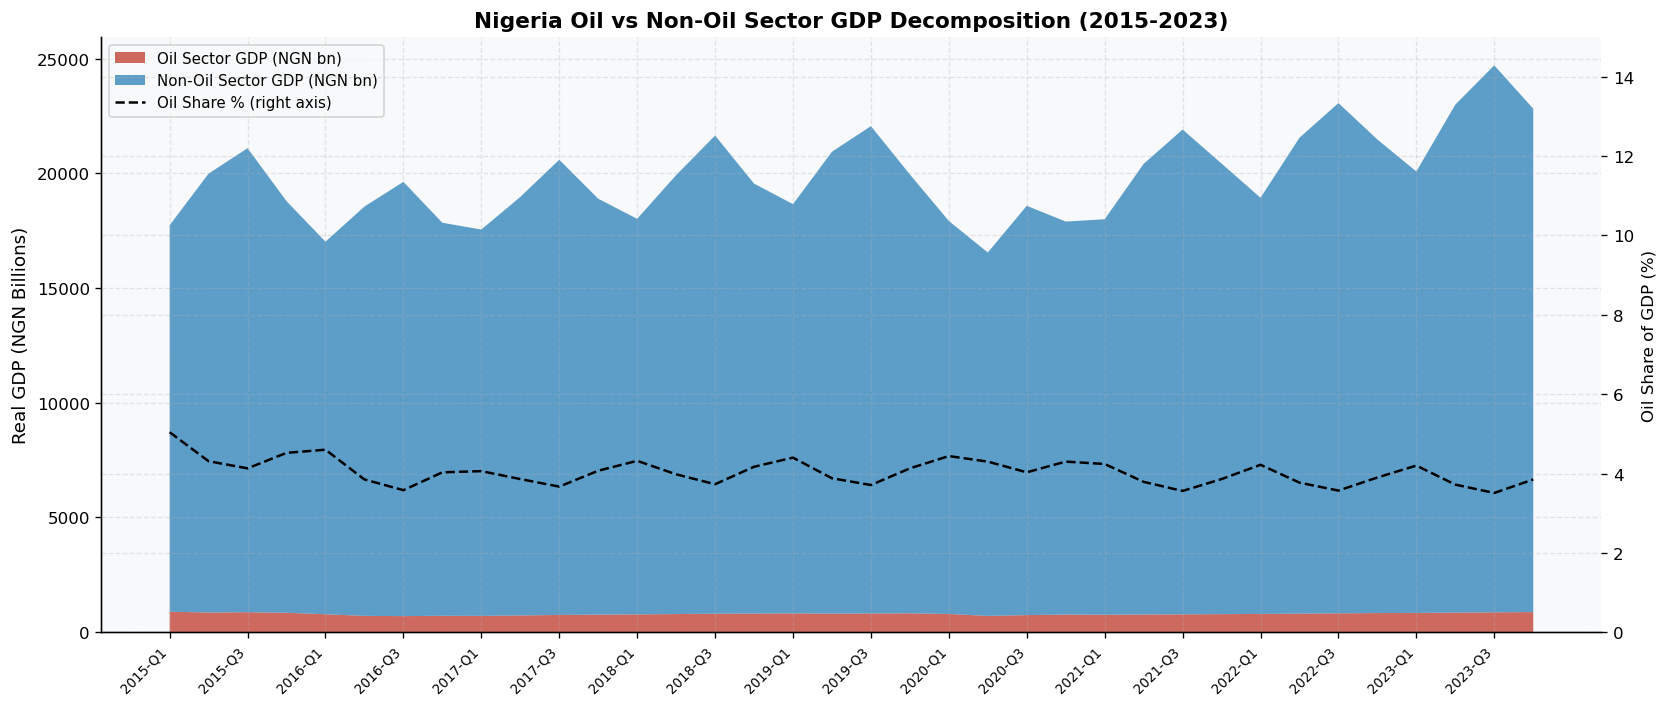

In [14]:
fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(gdp))
ax.stackplot(x, gdp['real_gdp_oil_ngn_bn'], gdp['real_gdp_nonoil_ngn_bn'],
             labels=['Oil Sector GDP (NGN bn)', 'Non-Oil Sector GDP (NGN bn)'],
             colors=[COLORS['oil'], COLORS['nonoil']], alpha=0.75)
ax2 = ax.twinx()
ax2.plot(x, gdp['oil_share_pct'], 'k--', linewidth=1.5, label='Oil Share % (right axis)')
ax2.set_ylabel('Oil Share of GDP (%)', fontsize=10)
ax2.set_ylim(0, 15)
ax.set_xticks(list(x)[::2])
ax.set_xticklabels(gdp['period'].iloc[::2], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Real GDP (NGN Billions)', fontsize=11)
ax.set_title('Nigeria Oil vs Non-Oil Sector GDP Decomposition (2015-2023)', fontsize=13, fontweight='bold')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'chart2_oil_nonoil_gdp.png'), dpi=120, bbox_inches='tight')
plt.show()

### Chart 3 - Monthly Inflation: Headline, Food and Core (2015-2023)

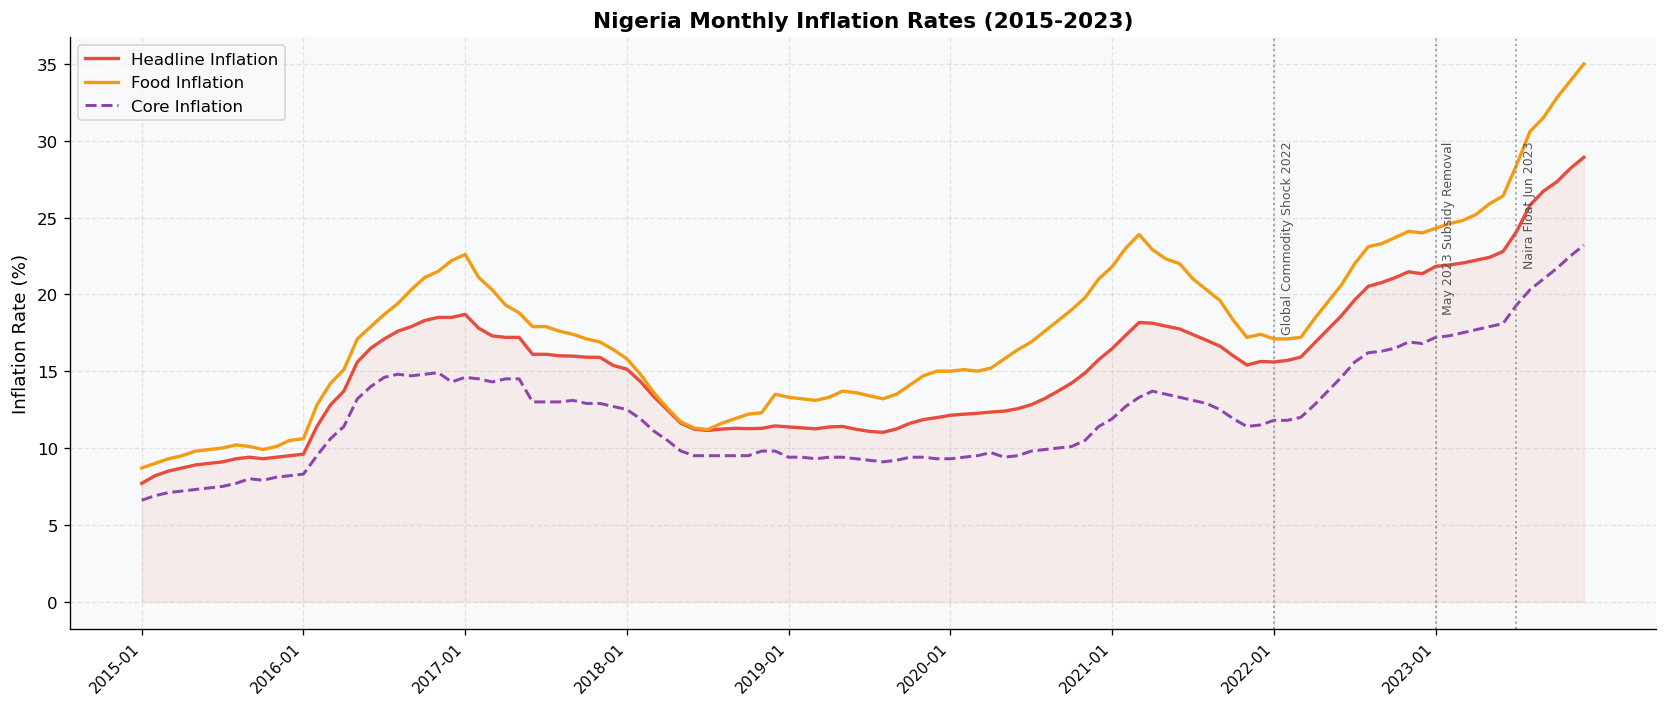

Peak inflation: 2023-12 (28.9%)


In [15]:
fig, ax = plt.subplots(figsize=(14, 6))
months = range(len(cpi))
ax.plot(months, cpi['headline_inflation_pct'], color=COLORS['headline'], linewidth=2,   label='Headline Inflation')
ax.plot(months, cpi['food_inflation_pct'],     color=COLORS['food'],     linewidth=2,   label='Food Inflation')
ax.plot(months, cpi['core_inflation_pct'],     color=COLORS['core'],     linewidth=1.8, label='Core Inflation', linestyle='--')
ax.fill_between(months, cpi['headline_inflation_pct'], alpha=0.08, color=COLORS['headline'])
for mo, label in [(84, 'Global Commodity Shock 2022'), (96, 'May 2023 Subsidy Removal'), (102, 'Naira Float Jun 2023')]:
    ax.axvline(mo, color='gray', linestyle=':', linewidth=1.2, alpha=0.7)
    ax.text(mo+0.5, 30, label, fontsize=7.5, color='#555', rotation=90, va='top')
tick_idx = list(range(0, len(cpi), 12))
ax.set_xticks(tick_idx)
ax.set_xticklabels([cpi['period'].iloc[i] for i in tick_idx], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Inflation Rate (%)', fontsize=11)
ax.set_title('Nigeria Monthly Inflation Rates (2015-2023)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'chart3_inflation_trends.png'), dpi=120, bbox_inches='tight')
plt.show()
print(f"Peak inflation: {cpi.loc[cpi['headline_inflation_pct'].idxmax(),'period']} ({cpi['headline_inflation_pct'].max():.1f}%)")

### Chart 4 - Oil Price vs GDP Growth Scatter

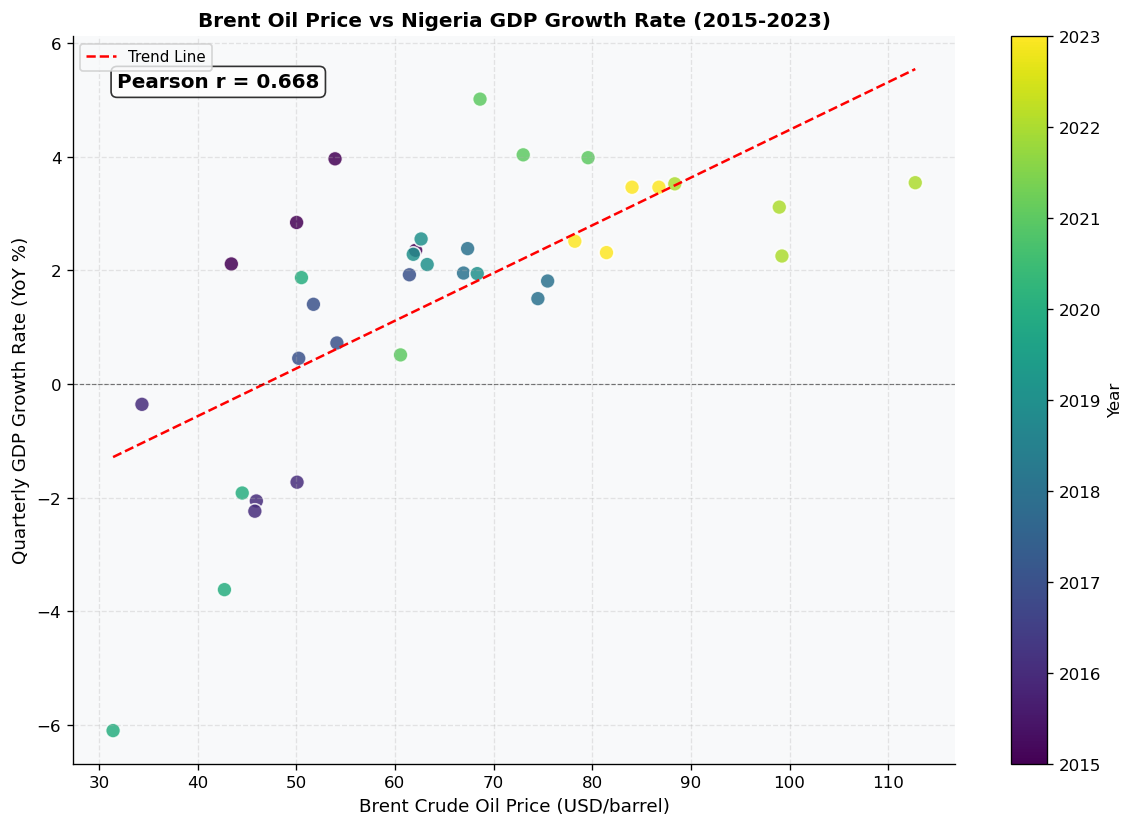

Pearson r = 0.668


In [17]:
brent_q = brent.assign(quarter=((brent['month']-1)//3)+1).groupby(['year','quarter'])['brent_price_usd'].mean().reset_index()
merged  = gdp.merge(brent_q, on=['year','quarter'], how='left')
fig, ax = plt.subplots(figsize=(10, 7))
years = merged['year'].unique()
cmap  = plt.cm.viridis
norm  = plt.Normalize(years.min(), years.max())
for yr in years:
    sub = merged[merged['year'] == yr]
    ax.scatter(sub['brent_price_usd'], sub['gdp_growth_yoy_pct'],
               c=[yr]*len(sub), cmap=cmap, norm=norm, s=80, alpha=0.85, edgecolors='white')
valid = merged.dropna(subset=['brent_price_usd','gdp_growth_yoy_pct'])
z  = np.polyfit(valid['brent_price_usd'], valid['gdp_growth_yoy_pct'], 1)
xs = np.linspace(valid['brent_price_usd'].min(), valid['brent_price_usd'].max(), 100)
ax.plot(xs, np.poly1d(z)(xs), 'r--', linewidth=1.5, label='Trend Line')
corr = valid['brent_price_usd'].corr(valid['gdp_growth_yoy_pct'])
ax.text(0.05, 0.95, f'Pearson r = {corr:.3f}', transform=ax.transAxes, fontsize=12,
        fontweight='bold', va='top', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.5)
plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Year')
ax.set_xlabel('Brent Crude Oil Price (USD/barrel)', fontsize=11)
ax.set_ylabel('Quarterly GDP Growth Rate (YoY %)', fontsize=11)
ax.set_title('Brent Oil Price vs Nigeria GDP Growth Rate (2015-2023)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'chart4_oil_gdp_scatter.png'), dpi=120, bbox_inches='tight')
plt.show()
print(f"Pearson r = {corr:.3f}")

### Chart 5 - Labour Force Indicators (Q1 2022 - Q4 2023)

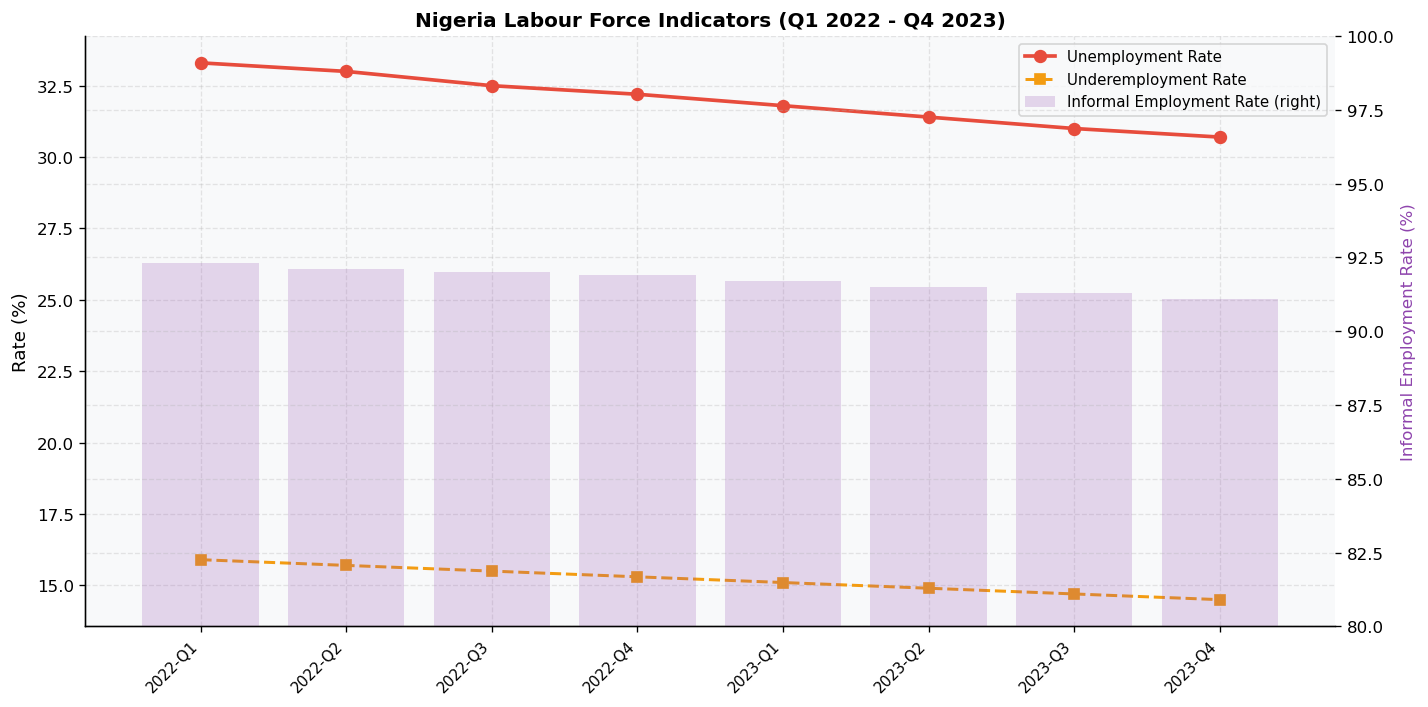

    period  unemployment_rate_pct  underemployment_rate_pct  \
0  2022-Q1                   33.3                      15.9   
1  2022-Q2                   33.0                      15.7   
2  2022-Q3                   32.5                      15.5   
3  2022-Q4                   32.2                      15.3   
4  2023-Q1                   31.8                      15.1   
5  2023-Q2                   31.4                      14.9   
6  2023-Q3                   31.0                      14.7   
7  2023-Q4                   30.7                      14.5   

   informal_employment_rate_pct  
0                          92.3  
1                          92.1  
2                          92.0  
3                          91.9  
4                          91.7  
5                          91.5  
6                          91.3  
7                          91.1  


In [18]:
fig, ax = plt.subplots(figsize=(12, 6))
x_lfs = range(len(lfs))
ax.plot(x_lfs, lfs['unemployment_rate_pct'],    'o-', color='#e74c3c', linewidth=2.2, markersize=7, label='Unemployment Rate')
ax.plot(x_lfs, lfs['underemployment_rate_pct'], 's--',color='#f39c12', linewidth=1.8, markersize=6, label='Underemployment Rate')
ax2 = ax.twinx()
ax2.bar(x_lfs, lfs['informal_employment_rate_pct'], alpha=0.2, color='#8e44ad', label='Informal Employment Rate (right)')
ax2.set_ylabel('Informal Employment Rate (%)', fontsize=10, color='#8e44ad')
ax2.set_ylim(80, 100)
ax.set_xticks(x_lfs)
ax.set_xticklabels(lfs['period'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Rate (%)', fontsize=11)
ax.set_title('Nigeria Labour Force Indicators (Q1 2022 - Q4 2023)', fontsize=12, fontweight='bold')
lines1, l1 = ax.get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, l1+l2, loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'chart5_labour_force.png'), dpi=120, bbox_inches='tight')
plt.show()
print(lfs[['period','unemployment_rate_pct','underemployment_rate_pct','informal_employment_rate_pct']])

---
## Task 1.4 - Geopolitical Zone and State Analysis

### Zone Average Unemployment

In [19]:
zone_avg = states.groupby('geopolitical_zone')['unemployment_rate_2023'].agg(['mean','min','max','count'])
zone_avg.columns = ['Mean','Min','Max','States']
print(zone_avg.sort_values('Mean', ascending=False).round(2).to_string())

                    Mean   Min   Max  States
geopolitical_zone                           
North-West         41.86  32.4  47.4       7
North-East         41.17  37.2  45.2       6
North-Central      33.29  12.8  38.8       7
South-East         30.18  22.4  34.6       5
South-South        25.23  18.4  29.6       6
South-West         23.80  14.2  30.2       6


### Chart 6 - Average Unemployment Rate by Zone

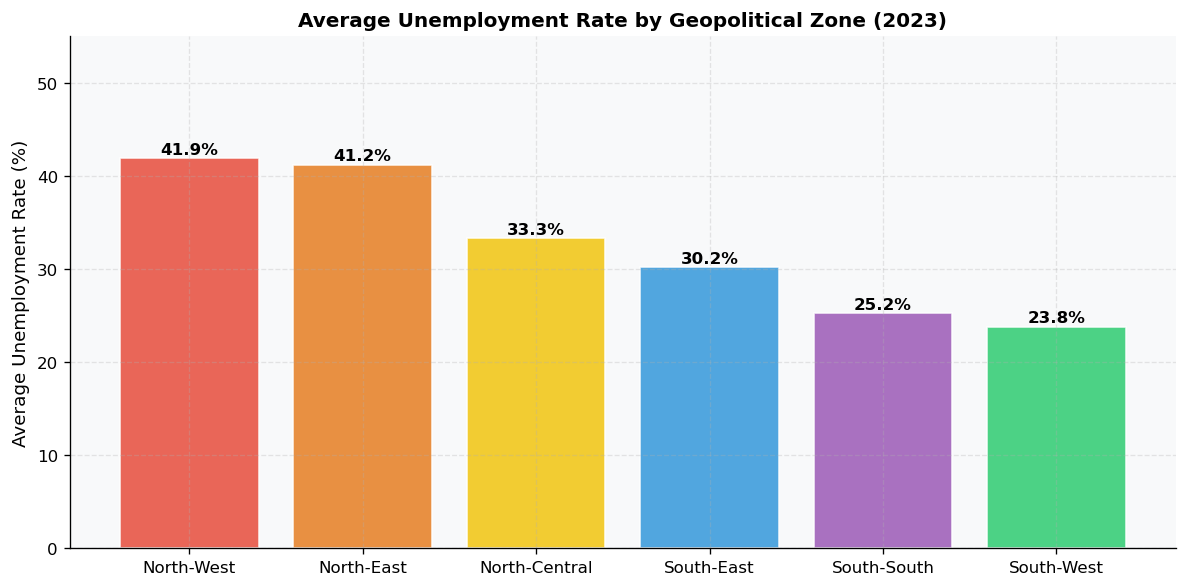

In [20]:
zone_palette = {
    'North-West':'#e74c3c','North-East':'#e67e22','North-Central':'#f1c40f',
    'South-West':'#2ecc71','South-East':'#3498db','South-South':'#9b59b6'
}
zone_avg_s = states.groupby('geopolitical_zone')['unemployment_rate_2023'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(zone_avg_s.index, zone_avg_s.values,
              color=[zone_palette[z] for z in zone_avg_s.index], alpha=0.85, edgecolor='white')
for bar, val in zip(bars, zone_avg_s.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Average Unemployment Rate (%)', fontsize=11)
ax.set_title('Average Unemployment Rate by Geopolitical Zone (2023)', fontsize=12, fontweight='bold')
ax.set_ylim(0, 55)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'chart6_zone_unemployment.png'), dpi=120, bbox_inches='tight')
plt.show()

### Chart 7 - All 36 States + FCT Ranked by Unemployment

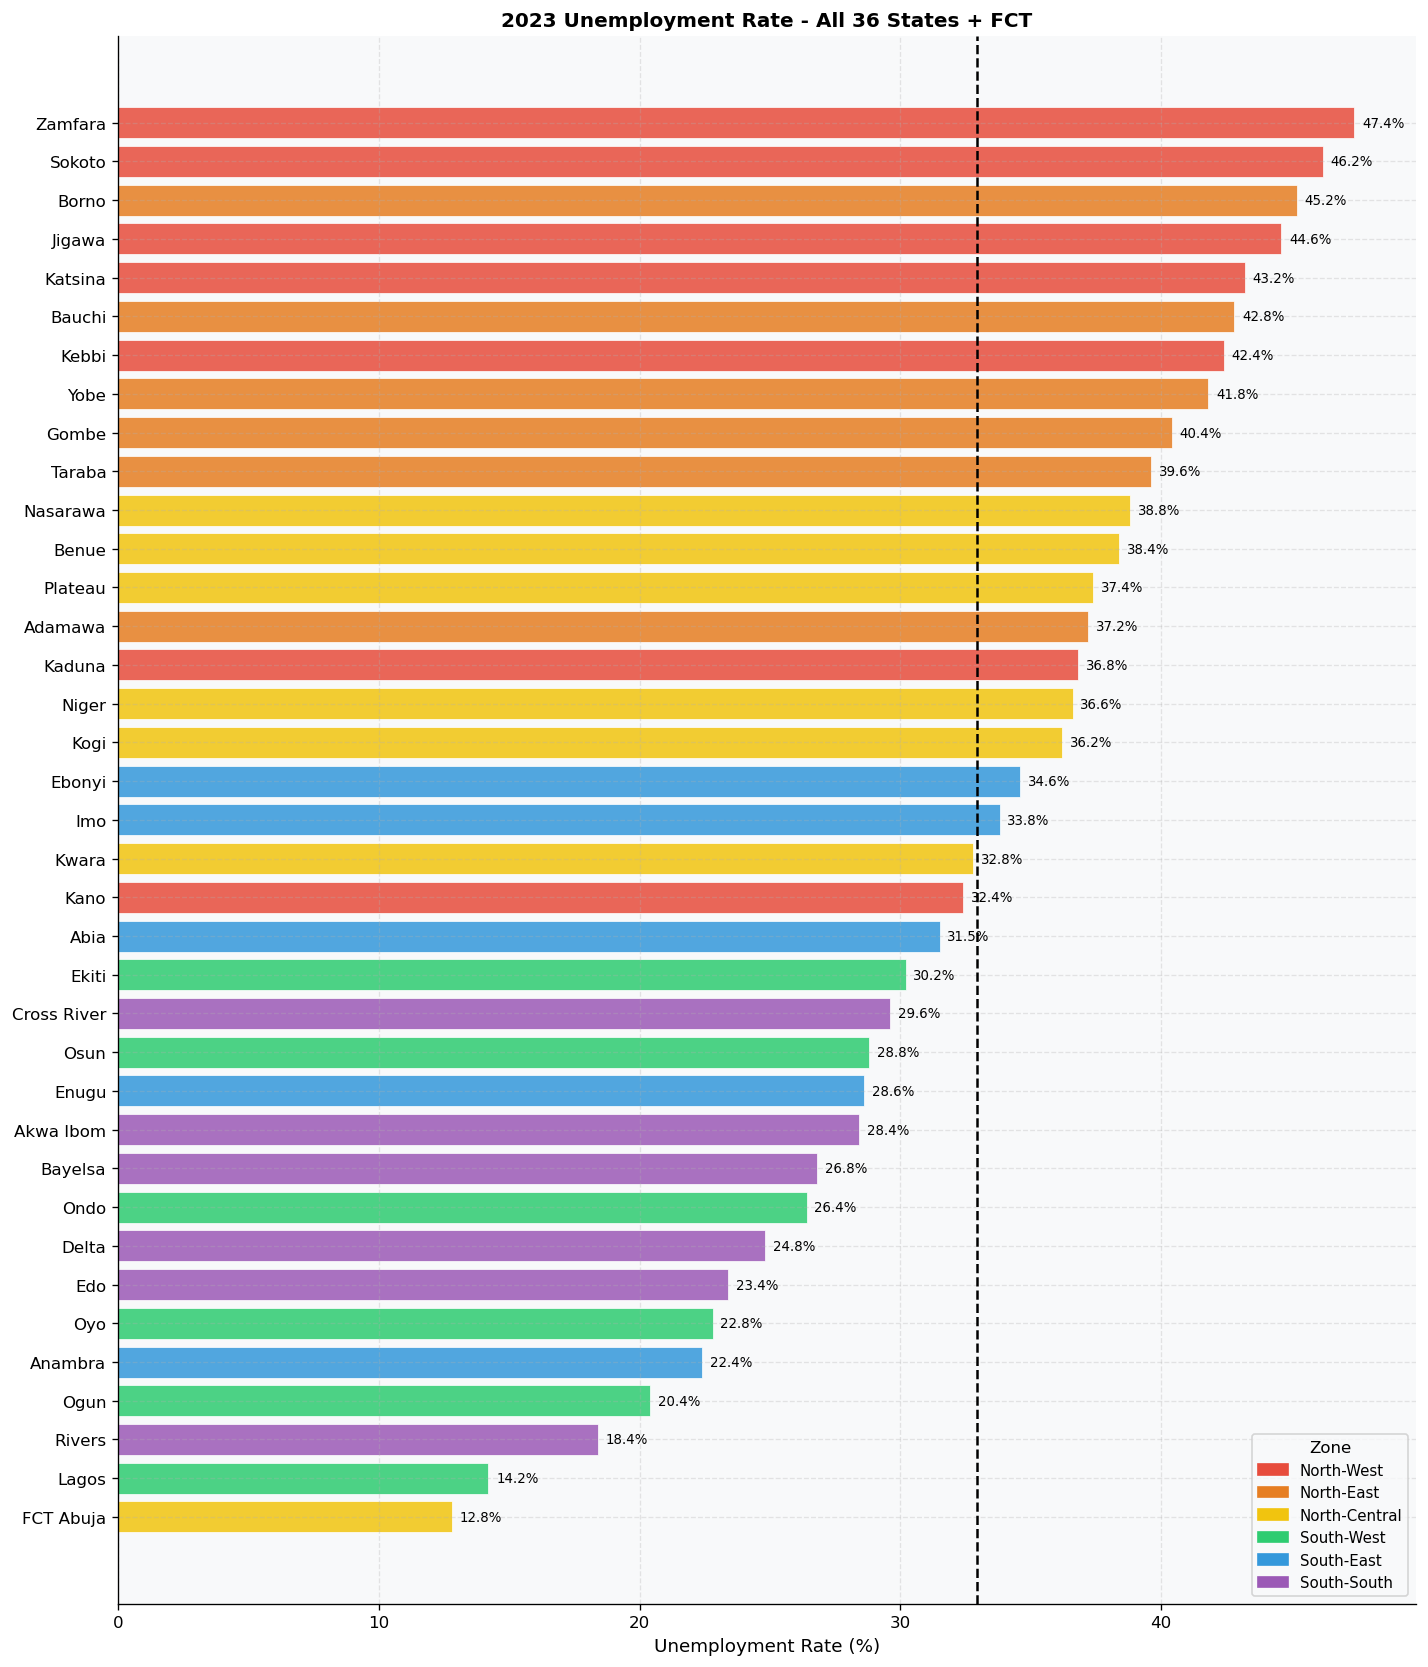

Highest: Zamfara (47.4%)
Lowest : FCT Abuja (12.8%)


In [21]:
states_sorted = states.sort_values('unemployment_rate_2023', ascending=True)
fig, ax = plt.subplots(figsize=(12, 14))
bar_colors = [zone_palette[z] for z in states_sorted['geopolitical_zone']]
bars = ax.barh(states_sorted['state'], states_sorted['unemployment_rate_2023'],
               color=bar_colors, edgecolor='white', linewidth=0.5, alpha=0.85)
for bar, val in zip(bars, states_sorted['unemployment_rate_2023']):
    ax.text(val+0.3, bar.get_y()+bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=8)
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in zone_palette.items()]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9, title='Zone')
national_avg = states['unemployment_rate_2023'].mean()
ax.axvline(national_avg, color='black', linestyle='--', linewidth=1.5)
ax.set_xlabel('Unemployment Rate (%)', fontsize=11)
ax.set_title('2023 Unemployment Rate - All 36 States + FCT', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'chart7_state_ranking.png'), dpi=120, bbox_inches='tight')
plt.show()
print(f"Highest: {states.loc[states['unemployment_rate_2023'].idxmax(),'state']} ({states['unemployment_rate_2023'].max():.1f}%)")
print(f"Lowest : {states.loc[states['unemployment_rate_2023'].idxmin(),'state']} ({states['unemployment_rate_2023'].min():.1f}%)")

### Chart 8 - Urban-Rural Unemployment Gap by Zone

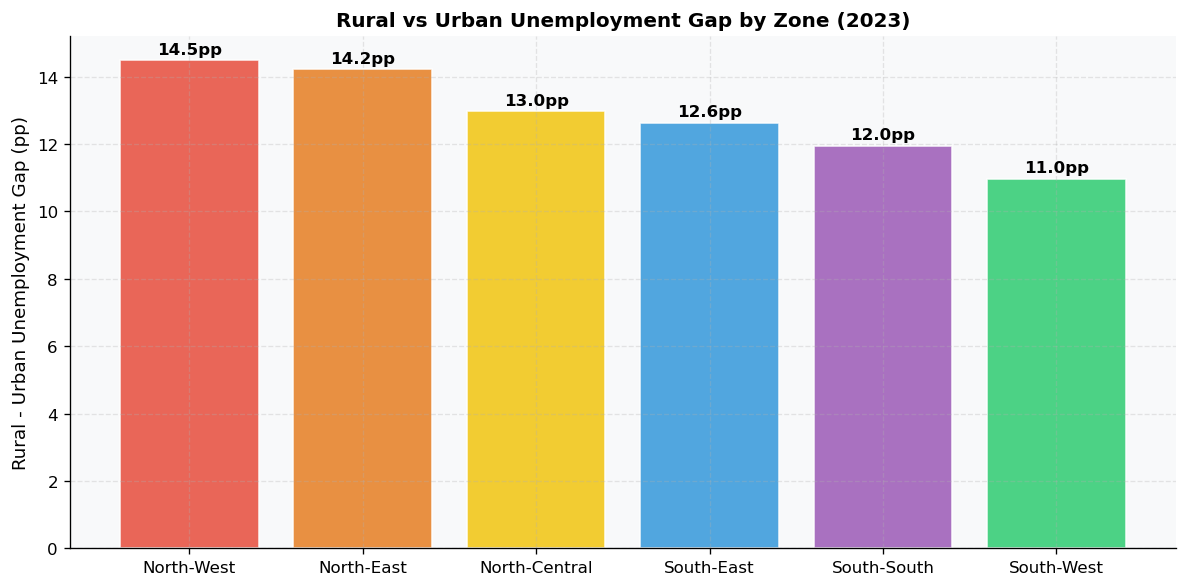

geopolitical_zone
North-West       14.485714
North-East       14.216667
North-Central    12.971429
South-East       12.640000
South-South      11.950000
South-West       10.966667
Name: urban_rural_gap, dtype: float64


In [22]:
states['urban_rural_gap'] = states['rural_unemployment_2023'] - states['urban_unemployment_2023']
gap_zone = states.groupby('geopolitical_zone')['urban_rural_gap'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(gap_zone.index, gap_zone.values,
              color=[zone_palette[z] for z in gap_zone.index], alpha=0.85, edgecolor='white')
for bar, val in zip(bars, gap_zone.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, f'{val:.1f}pp', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Rural - Urban Unemployment Gap (pp)', fontsize=11)
ax.set_title('Rural vs Urban Unemployment Gap by Zone (2023)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'chart8_urban_rural_gap.png'), dpi=120, bbox_inches='tight')
plt.show()
print(gap_zone)

### Chart 9 - Nigeria Choropleth Map (State Unemployment)

In [23]:
import folium
from folium import Choropleth

centroids = pd.read_csv('nigeria_state_centroids.csv')
with open('nigeria_states_simplified.geojson') as f:
    geo = json.load(f)

unem_dict = states.set_index('state')['unemployment_rate_2023'].to_dict()
for feature in geo['features']:
    feature['properties']['unemployment_rate_2023'] = unem_dict.get(feature['properties']['state'], 0)

m = folium.Map(location=[9.08, 8.68], zoom_start=6, tiles='CartoDB positron', control_scale=True)
Choropleth(
    geo_data=geo, name='Unemployment Rate 2023', data=states,
    columns=['state','unemployment_rate_2023'], key_on='feature.properties.state',
    fill_color='YlOrRd', fill_opacity=0.75, line_opacity=0.4,
    legend_name='Unemployment Rate 2023 (%)',
).add_to(m)

merged_map = centroids.merge(states[['state','unemployment_rate_2023','geopolitical_zone']], on='state', suffixes=('_c','_s'))
zone_col = 'geopolitical_zone_s' if 'geopolitical_zone_s' in merged_map.columns else 'geopolitical_zone'
for _, row in merged_map.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5, color='black', fill=True, fill_opacity=0.7, weight=1,
        tooltip=folium.Tooltip(f"<b>{row['state']}</b><br>Zone: {row[zone_col]}<br>Unemployment: {row['unemployment_rate_2023']:.1f}%")
    ).add_to(m)

folium.LayerControl().add_to(m)
m.save(os.path.join(OUTPUT, 'chart9_nigeria_choropleth.html'))
print("Choropleth map saved. Open chart9_nigeria_choropleth.html in your browser to view it.")
m

Choropleth map saved. Open chart9_nigeria_choropleth.html in your browser to view it.


---
## Module 1 Summary

Key findings:
- Nigeria GDP contracted -6.1% in Q2 2020 (COVID trough), recovering to +5.0% by Q2 2021
- Headline inflation surged from 22.8% to 28.9% in the 6 months following June 2023 subsidy removal
- Oil price has a moderate positive correlation with GDP growth (Pearson r = 0.668)
- Zamfara has the highest state unemployment (47.4%); FCT Abuja the lowest (12.8%)
- Northern zones average unemployment ~18 percentage points higher than Southern zones
- National informal employment rate exceeds 91% across all quarters (2022-2023)